In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/Users/metinyazar/Desktop/drug_resistance_ppi/new_analysis_after_new_agg_21082025/results/4_ML_graphs/knoll_dataset_model_predictions_score_causal.csv")
df

,Gene,Score,Label
0,CARM1,0.144092,1
1,NME6,0.111583,1
2,KDM1A,0.131834,1
3,CAB39,0.102617,1
4,NRDC,0.121942,1
...,...,...,...
4534,MAPK1,0.126756,0
4535,ZFP36L1,0.113831,0
4536,RAF1,0.092397,0
4537,PTEN,0.136537,0


Empirical top-k probabilities (MTAP case study):

N= 10 → Top-1=0.229, Top-3=0.559, Top-5=0.773
N= 20 → Top-1=0.131, Top-3=0.333, Top-5=0.506
N= 50 → Top-1=0.060, Top-3=0.161, Top-5=0.246


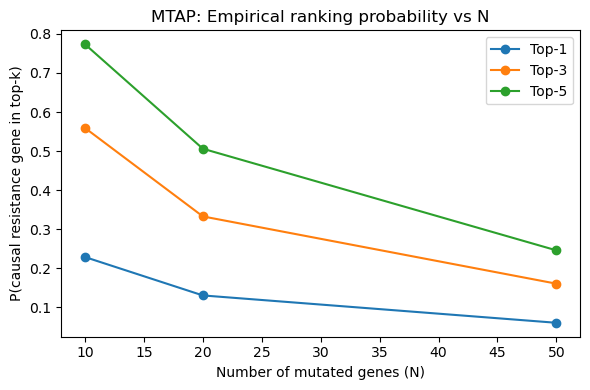

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example input DataFrame: df with 'Gene', 'Score', 'Label' columns
# 1 = resistance gene, 0 = non-resistance
# df = pd.read_csv("mtap_predictions.csv")

def empirical_hitk(df, N_list=(10,20,50), k_list=(1,3,5), trials=20000, rng=None):
    """
    Empirically estimate how often a true resistance gene ranks in the top-k
    among N candidates (1 positive + N-1 negatives).
    """
    rng = np.random.default_rng() if rng is None else rng
    pos_scores = df.loc[df["Label"] == 1, "Score"].values
    neg_scores = df.loc[df["Label"] == 0, "Score"].values

    results = {(N, k): 0 for N in N_list for k in k_list}

    for N in N_list:
        for _ in range(trials):
            # sample 1 resistance and N-1 other genes
            s_causal = rng.choice(pos_scores)
            s_non = rng.choice(neg_scores, size=N-1, replace=False if len(neg_scores)>=N-1 else True)

            rank = 1 + np.sum(s_non > s_causal)  # 1 = best
            for k in k_list:
                if rank <= k:
                    results[(N, k)] += 1

        for k in k_list:
            results[(N, k)] /= trials

    return results


# ---- Run it on your MTAP model scores ----
hitk_results = empirical_hitk(df, N_list=[10,20,50], k_list=[1,3,5], trials=20000, rng=np.random.default_rng(42))

# Print summary table
print("Empirical top-k probabilities (MTAP case study):\n")
for N in [10,20,50]:
    vals = [hitk_results[(N,k)] for k in [1,3,5]]
    print(f"N={N:>3} → Top-1={vals[0]:.3f}, Top-3={vals[1]:.3f}, Top-5={vals[2]:.3f}")

# ---- Plot figure for paper/presentation ----
plt.figure(figsize=(6,4))
for k in [1,3,5]:
    y = [hitk_results[(N,k)] for N in [10,20,50]]
    plt.plot([10,20,50], y, marker="o", label=f"Top-{k}")
plt.xlabel("Number of mutated genes (N)")
plt.ylabel("P(causal resistance gene in top-k)")
plt.title("MTAP: Empirical ranking probability vs N")
plt.legend()
plt.tight_layout()
plt.savefig("mtap_empirical_hitk.jpeg", dpi=600)
plt.show()


Empirical top-k probabilities (MTAP case study):

N=  5 → Top-1=0.390, Top-3=0.818, Top-5=1.000
N= 10 → Top-1=0.229, Top-3=0.556, Top-5=0.775
N= 15 → Top-1=0.170, Top-3=0.421, Top-5=0.607
N= 20 → Top-1=0.128, Top-3=0.341, Top-5=0.498
N= 25 → Top-1=0.112, Top-3=0.275, Top-5=0.427
N= 30 → Top-1=0.093, Top-3=0.230, Top-5=0.368
N= 35 → Top-1=0.082, Top-3=0.216, Top-5=0.325
N= 40 → Top-1=0.076, Top-3=0.191, Top-5=0.296
N= 45 → Top-1=0.069, Top-3=0.172, Top-5=0.261
N= 50 → Top-1=0.060, Top-3=0.159, Top-5=0.244


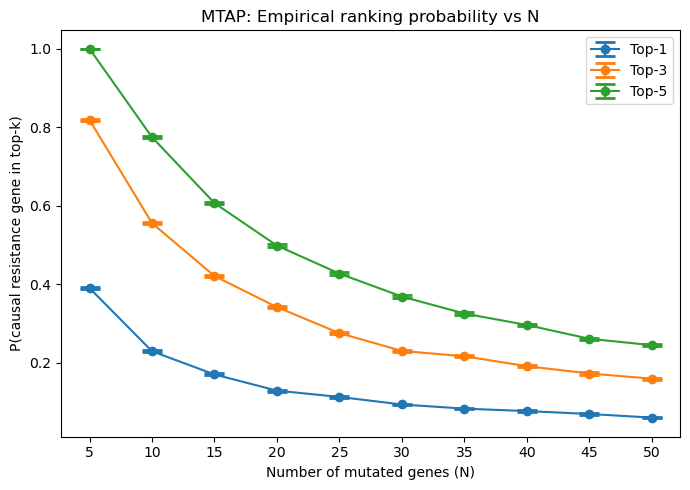

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def empirical_hitk_with_error(df, N_list, k_list=(1,3,5), trials=20000, rng=None):
    """
    Estimate how often a true resistance gene ranks in the top-k among N candidates (1 positive + N-1 negatives),
    and compute standard error over the trials.
    """
    rng = np.random.default_rng() if rng is None else rng
    pos_scores = df.loc[df["Label"] == 1, "Score"].values
    neg_scores = df.loc[df["Label"] == 0, "Score"].values

    results = {}
    errors = {}

    for N in N_list:
        for k in k_list:
            counts = []
            for _ in range(trials):
                s_causal = rng.choice(pos_scores)
                s_non = rng.choice(neg_scores, size=N-1, replace=False if len(neg_scores) >= N-1 else True)
                rank = 1 + np.sum(s_non > s_causal)
                counts.append(rank <= k)
            counts = np.array(counts)
            results[(N, k)] = counts.mean()
            errors[(N, k)] = counts.std(ddof=1) / np.sqrt(trials)  # Standard error

    return results, errors

# ---- Load your data ----
# df = pd.read_csv("mtap_predictions.csv")  # ensure it has 'Gene', 'Score', 'Label'

# ---- Run the empirical hit-k analysis ----
N_list = [5,10,15,20,25,30,35,40,45,50]
hitk_results, hitk_errors = empirical_hitk_with_error(df, N_list=N_list, k_list=[1,3,5], trials=20000, rng=np.random.default_rng(42))

# ---- Print summary ----
print("Empirical top-k probabilities (MTAP case study):\n")
for N in N_list:
    vals = [hitk_results[(N,k)] for k in [1,3,5]]
    print(f"N={N:>3} → Top-1={vals[0]:.3f}, Top-3={vals[1]:.3f}, Top-5={vals[2]:.3f}")

# ---- Plot with error bars ----
plt.figure(figsize=(7,5))
for k in [1,3,5]:
    y = [hitk_results[(N,k)] for N in N_list]
    yerr = [hitk_errors[(N,k)] for N in N_list]
    plt.errorbar(
    N_list, y, yerr=yerr,
    marker="o", label=f"Top-{k}",
    capsize=7, capthick=2, elinewidth=1.5
)

plt.xlabel("Number of mutated genes (N)")
plt.ylabel("P(causal resistance gene in top-k)")
plt.xticks(N_list)  # Ensures x-axis ticks match N values
plt.title("MTAP: Empirical ranking probability vs N")
plt.legend()
plt.tight_layout()
plt.savefig("mtap_empirical_hitk_with_error.jpeg", dpi=600)
plt.show()


Empirical top-k probabilities (MTAP case study):

N=  5 → Top-1=0.390, Top-3=0.818, Top-5=1.000
N= 10 → Top-1=0.229, Top-3=0.556, Top-5=0.775
N= 15 → Top-1=0.170, Top-3=0.421, Top-5=0.607
N= 20 → Top-1=0.128, Top-3=0.341, Top-5=0.498
N= 25 → Top-1=0.112, Top-3=0.275, Top-5=0.427
N= 30 → Top-1=0.093, Top-3=0.230, Top-5=0.368
N= 35 → Top-1=0.082, Top-3=0.216, Top-5=0.325
N= 40 → Top-1=0.076, Top-3=0.191, Top-5=0.296
N= 45 → Top-1=0.069, Top-3=0.172, Top-5=0.261
N= 50 → Top-1=0.060, Top-3=0.159, Top-5=0.244


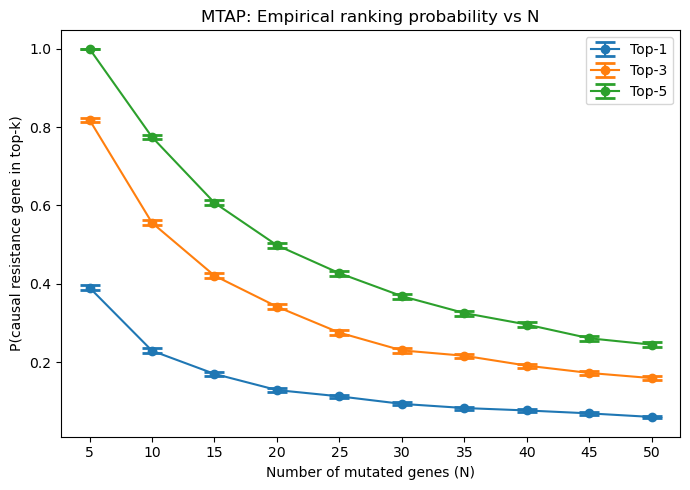

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def empirical_hitk_with_error(df, N_list, k_list=(1,3,5), trials=20000, rng=None):
    """
    Estimate how often a true resistance gene ranks in the top-k among N candidates (1 positive + N-1 negatives),
    and compute standard error over the trials.
    """
    rng = np.random.default_rng() if rng is None else rng
    pos_scores = df.loc[df["Label"] == 1, "Score"].values
    neg_scores = df.loc[df["Label"] == 0, "Score"].values

    results = {}
    errors = {}

    for N in N_list:
        for k in k_list:
            counts = []
            for _ in range(trials):
                s_causal = rng.choice(pos_scores)
                s_non = rng.choice(neg_scores, size=N-1, replace=False if len(neg_scores) >= N-1 else True)
                rank = 1 + np.sum(s_non > s_causal)
                counts.append(rank <= k)
            counts = np.array(counts)
            results[(N, k)] = counts.mean()
            errors[(N, k)] = 1.96 * counts.std(ddof=1) / np.sqrt(trials)  # 95% confidence interval

    return results, errors

# ---- Load your data ----
# df = pd.read_csv("mtap_predictions.csv")  # ensure it has 'Gene', 'Score', 'Label'

# ---- Run the empirical hit-k analysis ----
N_list = [5,10,15,20,25,30,35,40,45,50]
hitk_results, hitk_errors = empirical_hitk_with_error(df, N_list=N_list, k_list=[1,3,5], trials=20000, rng=np.random.default_rng(42))

# ---- Print summary ----
print("Empirical top-k probabilities (MTAP case study):\n")
for N in N_list:
    vals = [hitk_results[(N,k)] for k in [1,3,5]]
    print(f"N={N:>3} → Top-1={vals[0]:.3f}, Top-3={vals[1]:.3f}, Top-5={vals[2]:.3f}")

# ---- Plot with error bars ----
plt.figure(figsize=(7,5))
for k in [1,3,5]:
    y = [hitk_results[(N,k)] for N in N_list]
    yerr = [hitk_errors[(N,k)] for N in N_list]
    plt.errorbar(
    N_list, y, yerr=yerr,
    marker="o", label=f"Top-{k}",
    capsize=7, capthick=2, elinewidth=1.5
)

plt.xlabel("Number of mutated genes (N)")
plt.ylabel("P(causal resistance gene in top-k)")
plt.xticks(N_list)  # Ensures x-axis ticks match N values
plt.title("MTAP: Empirical ranking probability vs N")
plt.legend()
plt.tight_layout()
plt.savefig("mtap_empirical_hitk_with_error_95_confidence.jpeg", dpi=600)
plt.show()


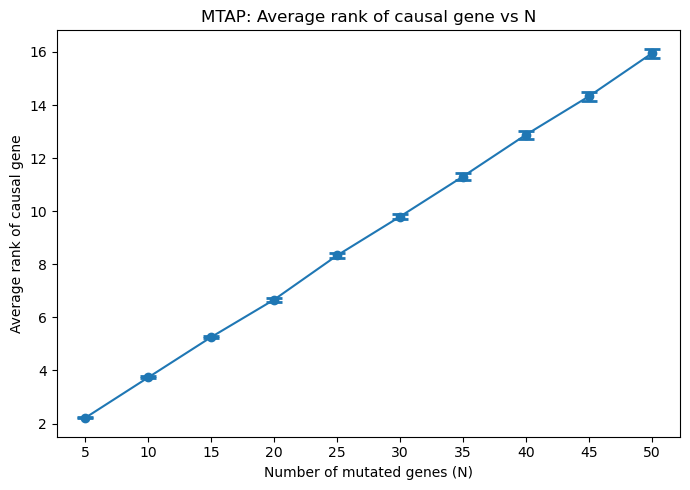

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def average_rank_of_causal(df, N_list, trials=20000, rng=None):
    """
    Estimate the average rank of a causal gene among N mutated genes across many trials.
    Returns the average and 95% CI (confidence interval) of the rank.
    """
    rng = np.random.default_rng() if rng is None else rng
    pos_scores = df.loc[df["Label"] == 1, "Score"].values
    neg_scores = df.loc[df["Label"] == 0, "Score"].values

    avg_ranks = []
    rank_cis = []

    for N in N_list:
        ranks = []
        for _ in range(trials):
            s_causal = rng.choice(pos_scores)
            s_non = rng.choice(neg_scores, size=N-1, replace=False if len(neg_scores) >= N-1 else True)
            rank = 1 + np.sum(s_non > s_causal)  # 1-based rank
            ranks.append(rank)
        ranks = np.array(ranks)
        avg_ranks.append(ranks.mean())
        rank_cis.append(1.96 * ranks.std(ddof=1) / np.sqrt(trials))  # 95% confidence interval

    return avg_ranks, rank_cis

# ---- Run average rank analysis ----
N_list = [5,10,15,20,25,30,35,40,45,50]
avg_ranks, rank_cis = average_rank_of_causal(df, N_list=N_list, trials=20000, rng=np.random.default_rng(42))

# ---- Plot average rank vs N ----
plt.figure(figsize=(7, 5))
plt.errorbar(N_list, avg_ranks, yerr=rank_cis, marker="o", capsize=6, capthick=2, elinewidth=1.5)
plt.xlabel("Number of mutated genes (N)")
plt.ylabel("Average rank of causal gene")
plt.title("MTAP: Average rank of causal gene vs N")
plt.xticks(N_list)
plt.tight_layout()
plt.savefig("mtap_avg_rank_vs_N.jpeg", dpi=600)
plt.show()


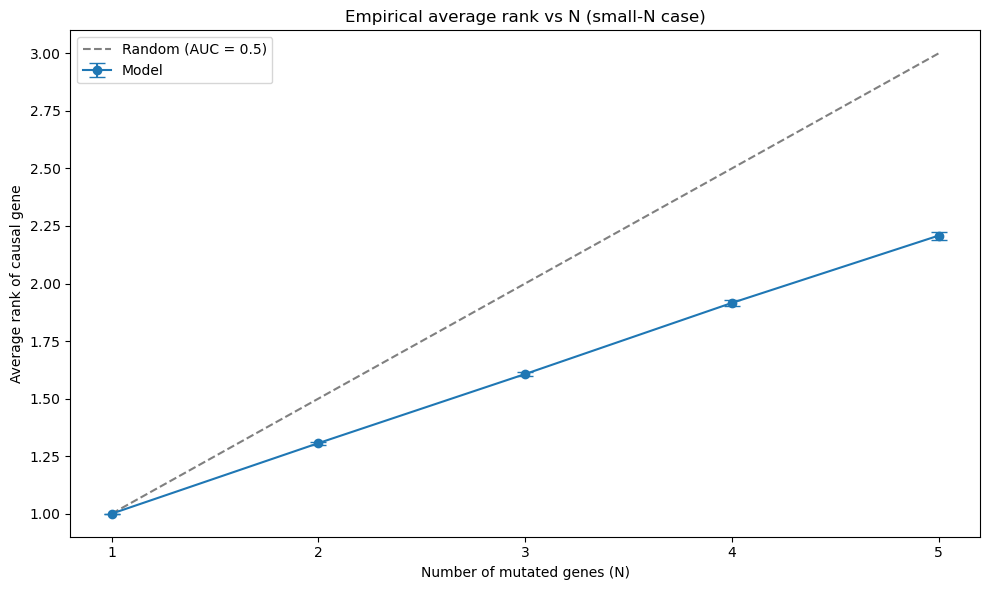

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def average_rank_of_causal(df, N_list, trials=20000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    pos_scores = df.loc[df["Label"] == 1, "Score"].values
    neg_scores = df.loc[df["Label"] == 0, "Score"].values

    avg_ranks = []
    rank_cis = []

    for N in N_list:
        ranks = []
        for _ in range(trials):
            s_causal = rng.choice(pos_scores)
            s_non = rng.choice(neg_scores, size=max(N-1, 0), replace=True)
            all_scores = np.append(s_non, s_causal)
            rank = 1 + np.sum(s_non > s_causal)  # 1-based rank
            ranks.append(rank)
        arr = np.array(ranks)
        avg_ranks.append(arr.mean())
        rank_cis.append(1.96 * arr.std(ddof=1) / np.sqrt(trials))  # 95% CI

    return avg_ranks, rank_cis

# === Load your data ===
# df = pd.read_csv("mtap_predictions.csv")  # ensure it has 'Gene', 'Score', 'Label'


# === Define small N range ===
N_list = [1, 2, 3, 4, 5]
avg_ranks, rank_cis = average_rank_of_causal(df, N_list=N_list, trials=20000, rng=np.random.default_rng(42))

# === Plot ===
plt.figure(figsize=(10, 6))
plt.errorbar(N_list, avg_ranks, yerr=rank_cis, marker="o", capsize=6, label="Model")
plt.plot(N_list, [(N + 1)/2 for N in N_list], linestyle="--", color="gray", label="Random (AUC = 0.5)")
plt.xlabel("Number of mutated genes (N)")
plt.ylabel("Average rank of causal gene")
plt.title("Empirical average rank vs N (small-N case)")
plt.xticks(N_list)
plt.legend()
plt.tight_layout()
plt.savefig("small_N_avg_rank_plot_2`.jpeg", dpi=600)
plt.show()


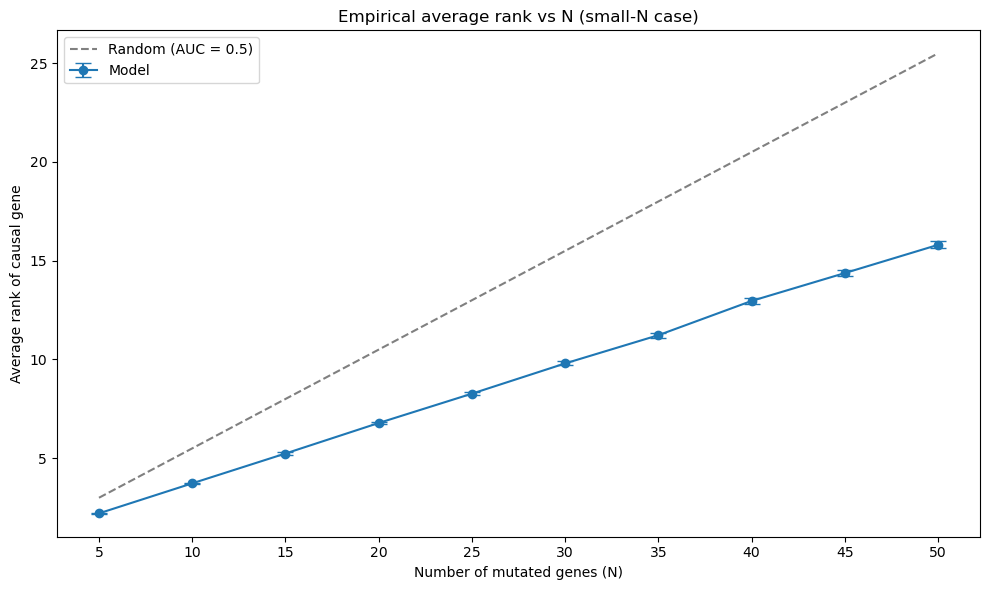

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def average_rank_of_causal(df, N_list, trials=20000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    pos_scores = df.loc[df["Label"] == 1, "Score"].values
    neg_scores = df.loc[df["Label"] == 0, "Score"].values

    avg_ranks = []
    rank_cis = []

    for N in N_list:
        ranks = []
        for _ in range(trials):
            s_causal = rng.choice(pos_scores)
            s_non = rng.choice(neg_scores, size=max(N-1, 0), replace=True)
            all_scores = np.append(s_non, s_causal)
            rank = 1 + np.sum(s_non > s_causal)  # 1-based rank
            ranks.append(rank)
        arr = np.array(ranks)
        avg_ranks.append(arr.mean())
        rank_cis.append(1.96 * arr.std(ddof=1) / np.sqrt(trials))  # 95% CI

    return avg_ranks, rank_cis

# === Load your data ===
# df = pd.read_csv("mtap_predictions.csv")  # ensure it has 'Gene', 'Score', 'Label'


# === Define small N range ===
N_list = [5,10,15,20,25,30,35,40,45,50]
avg_ranks, rank_cis = average_rank_of_causal(df, N_list=N_list, trials=20000, rng=np.random.default_rng(42))

# === Plot ===
plt.figure(figsize=(10, 6))
plt.errorbar(N_list, avg_ranks, yerr=rank_cis, marker="o", capsize=6, label="Model")
plt.plot(N_list, [(N + 1)/2 for N in N_list], linestyle="--", color="gray", label="Random (AUC = 0.5)")
plt.xlabel("Number of mutated genes (N)")
plt.ylabel("Average rank of causal gene")
plt.title("Empirical average rank vs N (small-N case)")
plt.xticks(N_list)
plt.legend()
plt.tight_layout()
plt.savefig("small_N_avg_rank_plot_3`.jpeg", dpi=600)
plt.show()


# Article 

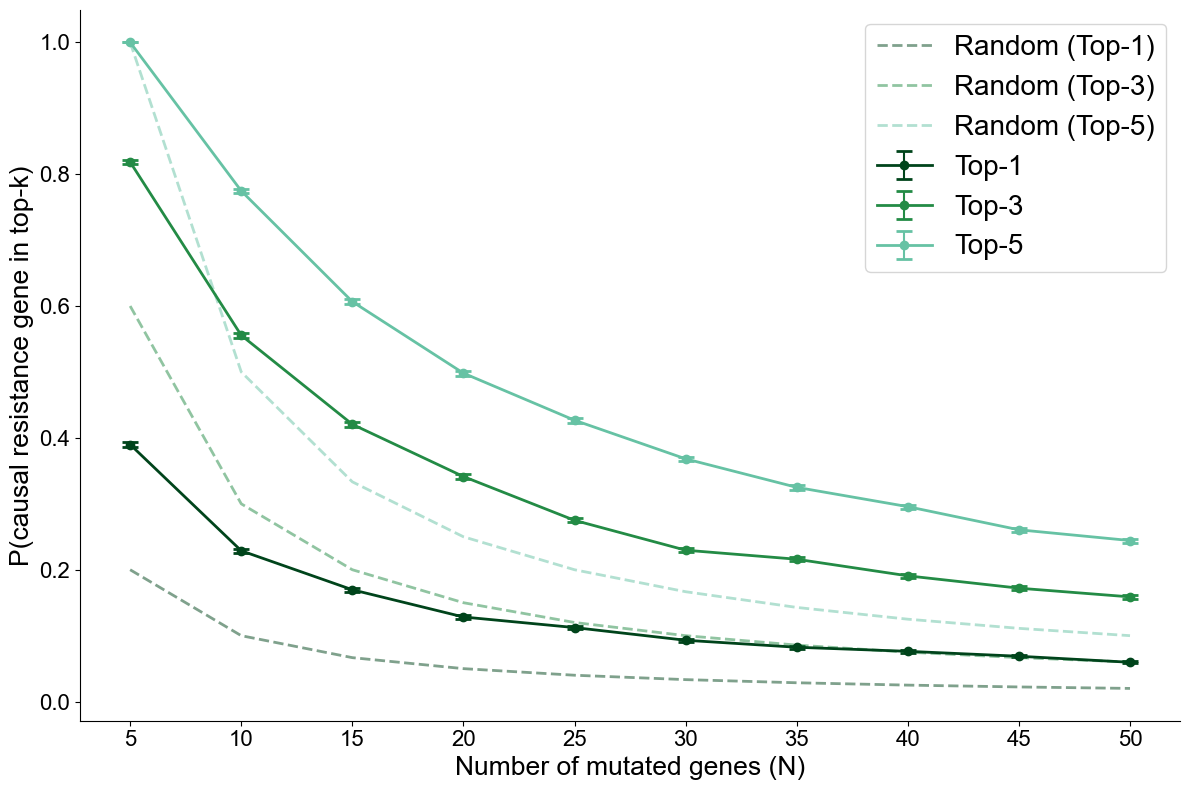

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/metinyazar/Desktop/drug_resistance_ppi/new_analysis_after_new_agg_21082025/results/4_ML_graphs/knoll_dataset_model_predictions_score_causal.csv")

# === Font Setup ===
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})
# Load your actual data here
# df = pd.read_csv("your_predictions.csv")  # must have 'Score' and 'Label'

# Dummy data for testing (REMOVE if using real data)
np.random.seed(42)

def empirical_hitk_with_error(df, N_list, k_list=(1,3,5), trials=20000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    pos_scores = df.loc[df["Label"] == 1, "Score"].values
    neg_scores = df.loc[df["Label"] == 0, "Score"].values

    results = {}
    errors = {}

    for N in N_list:
        for k in k_list:
            counts = []
            for _ in range(trials):
                s_causal = rng.choice(pos_scores)
                s_non = rng.choice(neg_scores, size=N-1, replace=False if len(neg_scores) >= N-1 else True)
                rank = 1 + np.sum(s_non > s_causal)
                counts.append(rank <= k)
            arr = np.array(counts)
            results[(N, k)] = arr.mean()
            errors[(N, k)] = arr.std(ddof=1) / np.sqrt(trials)
    return results, errors

# Run
N_list = [5,10,15,20,25,30,35,40,45,50]
hitk_results, hitk_errors = empirical_hitk_with_error(df, N_list=N_list, k_list=[1,3,5], trials=20000, rng=np.random.default_rng(42))

# === Plot ===
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

colors = ['#00441b', '#238b45', '#66c2a4']  # Dark to light green

plt.figure(figsize=(12, 8))
for idx, k in enumerate([1,3,5]):
    y = [hitk_results[(N,k)] for N in N_list]
    yerr = [hitk_errors[(N,k)] for N in N_list]
    plt.errorbar(
        N_list, y, yerr=yerr,
        marker="o", label=f"Top-{k}",
        capsize=6, capthick=2, elinewidth=1.5,
        linewidth=2, color=colors[idx]
    )

# === Add random baseline lines ===
for idx, k in enumerate([1, 3, 5]):
    y_random = [k / N for N in N_list]
    plt.plot(N_list, y_random, linestyle="--", linewidth=2, color=colors[idx], alpha=0.5,
             label=f"Random (Top-{k})")
plt.xlabel("Number of mutated genes (N)", fontsize=19)
plt.ylabel("P(causal resistance gene in top-k)", fontsize=19)
plt.xticks(N_list, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=20)
plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("mtap_empirical_hitk_with_error_pubready.jpeg", dpi=600)
plt.show()


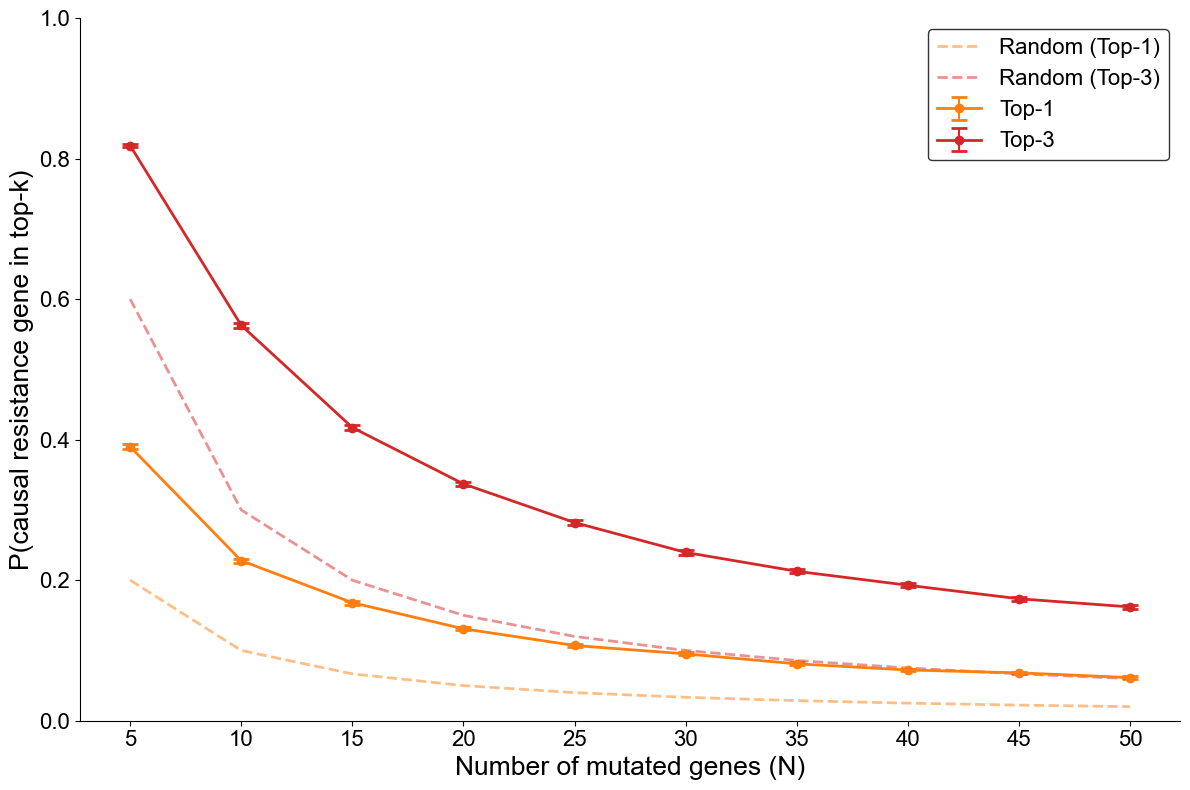

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/metinyazar/Desktop/drug_resistance_ppi/new_analysis_after_new_agg_21082025/results/4_ML_graphs/knoll_dataset_model_predictions_score_causal.csv")

# === Font Setup ===
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})
# Load your actual data here
# df = pd.read_csv("your_predictions.csv")  # must have 'Score' and 'Label'

# Dummy data for testing (REMOVE if using real data)
np.random.seed(42)

def empirical_hitk_with_error(df, N_list, k_list=(1,3), trials=20000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    pos_scores = df.loc[df["Label"] == 1, "Score"].values
    neg_scores = df.loc[df["Label"] == 0, "Score"].values

    results = {}
    errors = {}

    for N in N_list:
        for k in k_list:
            counts = []
            for _ in range(trials):
                s_causal = rng.choice(pos_scores)
                s_non = rng.choice(neg_scores, size=N-1, replace=False if len(neg_scores) >= N-1 else True)
                rank = 1 + np.sum(s_non > s_causal)
                counts.append(rank <= k)
            arr = np.array(counts)
            results[(N, k)] = arr.mean()
            errors[(N, k)] = arr.std(ddof=1) / np.sqrt(trials)
    return results, errors

# Run
N_list = [5,10,15,20,25,30,35,40,45,50]
hitk_results, hitk_errors = empirical_hitk_with_error(df, N_list=N_list, k_list=[1,3], trials=20000, rng=np.random.default_rng(42))

# === Plot ===
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# === Unified color per Top-k group ===
group_colors = {
    1: '#ff7f0e',  # orange
    3: '#d62728'   # red
}

plt.figure(figsize=(12, 8))

for k in [1, 3]:
    color = group_colors[k]

    # Model line
    y = [hitk_results[(N, k)] for N in N_list]
    yerr = [hitk_errors[(N, k)] for N in N_list]
    plt.errorbar(
        N_list, y, yerr=yerr,
        marker="o", label=f"Top-{k}",
        capsize=6, capthick=2, elinewidth=1.5,
        linewidth=2, color=color
    )

    # Random baseline line (same color, dashed)
    y_random = [k / N for N in N_list]
    plt.plot(
        N_list, y_random,
        linestyle="--", linewidth=2, color=color, alpha=0.5,
        label=f"Random (Top-{k})"
    )

# === Final plot styling ===
plt.ylim(0, 1)
plt.xlabel("Number of mutated genes (N)", fontsize=19)
plt.ylabel("P(causal resistance gene in top-k)", fontsize=19)
plt.xticks(N_list, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16, frameon=True, edgecolor='black')
plt.grid(False)

# Remove top/right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("mtap_empirical_hitk_with_error_pubready_2.jpeg", dpi=600)
plt.show()


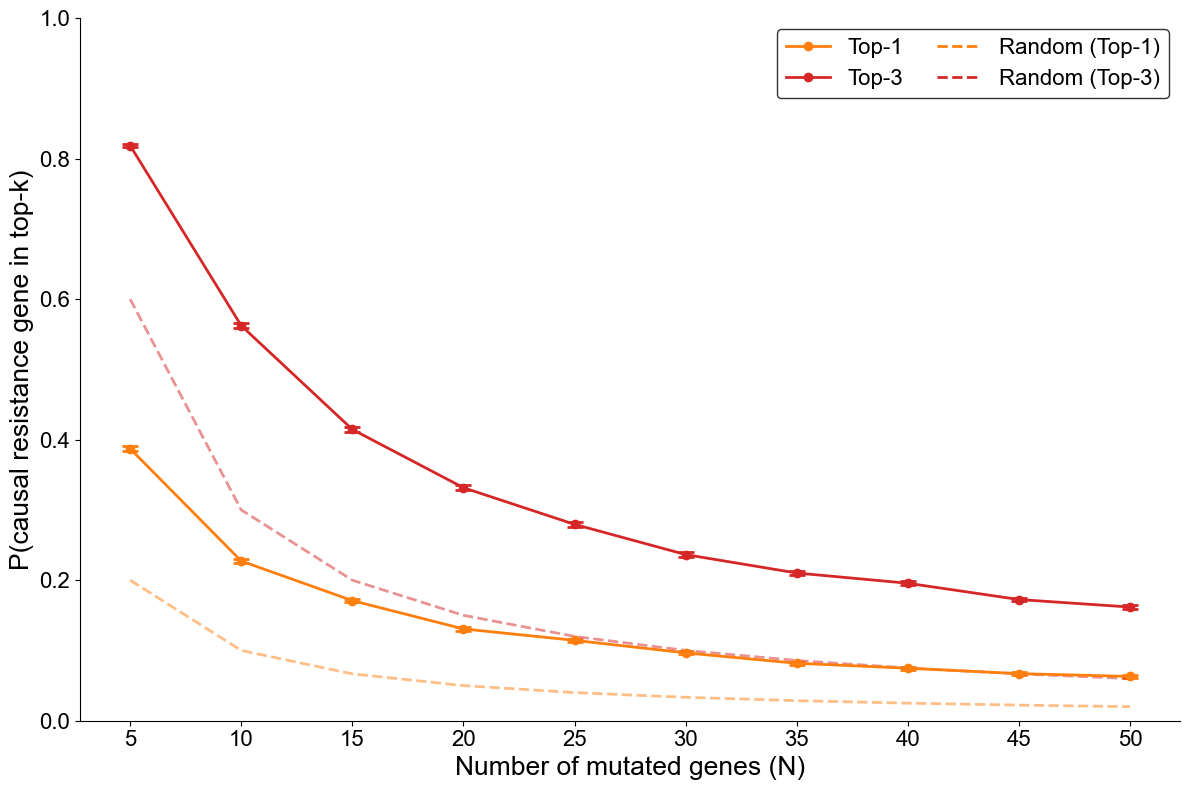

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df = pd.read_csv("/Users/metinyazar/Desktop/drug_resistance_ppi/new_analysis_after_new_agg_21082025/results/4_ML_graphs/knoll_dataset_model_predictions_score_causal.csv")

# === Font Setup ===
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})
# Load your actual data here
# df = pd.read_csv("your_predictions.csv")  # must have 'Score' and 'Label'

# Dummy data for testing (REMOVE if using real data)
np.random.seed(42)

def empirical_hitk_with_error(df, N_list, k_list=(1,3), trials=20000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    pos_scores = df.loc[df["Label"] == 1, "Score"].values
    neg_scores = df.loc[df["Label"] == 0, "Score"].values

    results = {}
    errors = {}

    for N in N_list:
        for k in k_list:
            counts = []
            for _ in range(trials):
                s_causal = rng.choice(pos_scores)
                s_non = rng.choice(neg_scores, size=N-1, replace=False if len(neg_scores) >= N-1 else True)
                rank = 1 + np.sum(s_non > s_causal)
                counts.append(rank <= k)
            arr = np.array(counts)
            results[(N, k)] = arr.mean()
            errors[(N, k)] = arr.std(ddof=1) / np.sqrt(trials)
    return results, errors

# Run
N_list = [5,10,15,20,25,30,35,40,45,50]
hitk_results, hitk_errors = empirical_hitk_with_error(df, N_list=N_list, k_list=[1,3], trials=20000, rng=np.random.default_rng(42))

# === Plot ===
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# === Unified color per Top-k group ===
group_colors = {
    1: '#ff7f0e',  # orange
    3: '#d62728'   # red
}

plt.figure(figsize=(12, 8))

for k in [1, 3]:
    color = group_colors[k]

    # Model line
    y = [hitk_results[(N, k)] for N in N_list]
    yerr = [hitk_errors[(N, k)] for N in N_list]
    plt.errorbar(
        N_list, y, yerr=yerr,
        marker="o", label=f"Top-{k}",
        capsize=6, capthick=2, elinewidth=1.5,
        linewidth=2, color=color
    )

    # Random baseline line (same color, dashed)
    y_random = [k / N for N in N_list]
    plt.plot(
        N_list, y_random,
        linestyle="--", linewidth=2, color=color, alpha=0.5,
        label=f"Random (Top-{k})"
    )

# === Final plot styling ===
plt.ylim(0, 1)
plt.xlabel("Number of mutated genes (N)", fontsize=19)
plt.ylabel("P(causal resistance gene in top-k)", fontsize=19)
plt.xticks(N_list, fontsize=16)
plt.yticks(fontsize=16)

# Custom legend elements
legend_model = [
    Line2D([0], [0], color=group_colors[k], marker='o', linestyle='-', label=f"Top-{k}", linewidth=2)
    for k in [1, 3]
]
legend_random = [
    Line2D([0], [0], color=group_colors[k], linestyle='--', label=f"Random (Top-{k})", linewidth=2)
    for k in [1, 3]
]

# Combine and display in two-column layout
plt.legend(
    handles=legend_model + legend_random,
    loc='upper right',
    fontsize=16,
    frameon=True,
    edgecolor='black',
    ncol=2,
    columnspacing=1.5
)
plt.grid(False)

# Remove top/right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("mtap_empirical_hitk_with_error_pubready_3.jpeg", dpi=600)
plt.show()
